In [61]:
# Toy Dataset
from sklearn.datasets import make_circles,make_moons,make_blobs
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten

In [62]:
data,target = make_circles(n_samples=1000,noise=0.03)

In [63]:
data[:5]

array([[-0.73313501, -0.33243982],
       [-0.93933696,  0.12748983],
       [ 0.99445742, -0.05919605],
       [-0.90239229, -0.14225718],
       [ 0.82638459,  0.19291522]])

In [64]:
target[:5]

array([1, 0, 0, 0, 1])

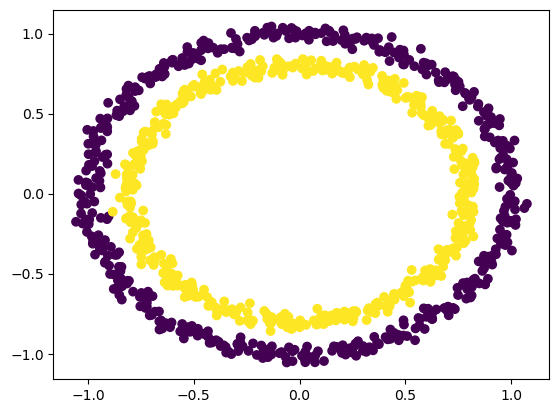

In [65]:
plt.scatter(data[:,0],data[:,1],c=target)
plt.show()

In [183]:
model = Sequential([  #we will create  a stack of layers  #tf.keras.model.Sequential
    tf.keras.layers.Dense(4,input_shape=(2,)),
    #Input(shape=[None,2]),  #Input Layer -> None will be replace by no. of rows by default
    Dense(4,activation="relu"),  #Adds Hidden Layer  with 4 neurons  ->tf.keras.layers..Dense()
    Dense(4,activation="relu"),
    Dense(4,activation="relu"),
    Dense(4,activation="relu"),
    Dense(1,activation="sigmoid")  #Output Layer with one neuron -> one more hidden layer
])

In [184]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                     │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [185]:
X_train,X_test,y_train,y_test = train_test_split(data,target,test_size=0.25)

In [186]:
X_train.shape

(750, 2)

In [187]:
X_test.shape

(250, 2)

In [188]:
loss = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer = optimizer,loss =loss,metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs=100,validation_data = (X_test,y_test))
#By default it uses linear for non-linear we need activation function

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4947 - loss: 0.6908 - val_accuracy: 0.5240 - val_loss: 0.6821
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5080 - loss: 0.6884 - val_accuracy: 0.5400 - val_loss: 0.6817
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5133 - loss: 0.6867 - val_accuracy: 0.5520 - val_loss: 0.6816
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5200 - loss: 0.6854 - val_accuracy: 0.5560 - val_loss: 0.6817
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5667 - loss: 0.6843 - val_accuracy: 0.5720 - val_loss: 0.6819
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5720 - loss: 0.6835 - val_accuracy: 0.5600 - val_loss: 0.6823
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5773 - loss: 0.6827 - val_accuracy: 0.5640 - val_loss: 0.6825
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5827 - loss: 0.6820 - val_accuracy: 0.

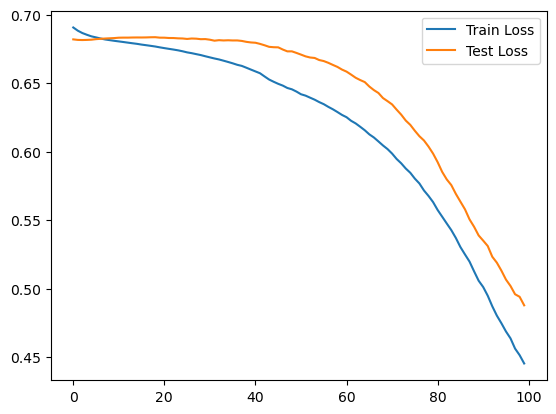

In [196]:
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Test Loss")
plt.legend()
plt.show()

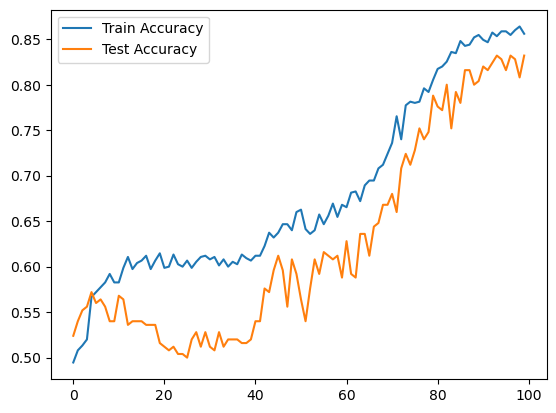

In [197]:
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Test Accuracy")
plt.legend()
plt.show()

In [198]:
y_pred = model.predict(x=X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [199]:
y_pred

array([[0.09669708],
       [0.2136872 ],
       [0.73720586],
       [0.28373587],
       [0.74407864],
       [0.20229134],
       [0.6105375 ],
       [0.16161434],
       [0.28424746],
       [0.74111235],
       [0.7462789 ],
       [0.613405  ],
       [0.49375945],
       [0.26393706],
       [0.27489346],
       [0.19694959],
       [0.16682476],
       [0.6671237 ],
       [0.56107515],
       [0.13077757],
       [0.7392262 ],
       [0.653913  ],
       [0.18366428],
       [0.517508  ],
       [0.7392262 ],
       [0.7548855 ],
       [0.6495662 ],
       [0.29474738],
       [0.19204718],
       [0.6045823 ],
       [0.43872687],
       [0.32259983],
       [0.7541236 ],
       [0.7336764 ],
       [0.6920774 ],
       [0.7406077 ],
       [0.31659645],
       [0.7405319 ],
       [0.21491246],
       [0.1712652 ],
       [0.20429349],
       [0.3949425 ],
       [0.6667547 ],
       [0.75024235],
       [0.4112158 ],
       [0.22022185],
       [0.18358709],
       [0.598

In [200]:
y_pred = np.round(y_pred)
y_pred

array([[0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],

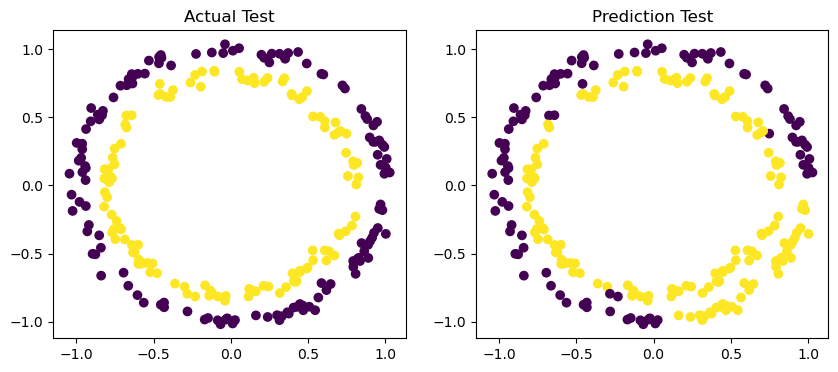

In [201]:
#Actual Data
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Actual Test")
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.subplot(1,2,2)
plt.title("Prediction Test")
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

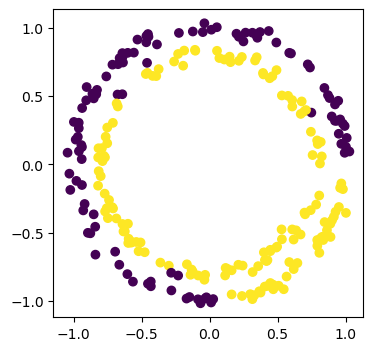

In [195]:
#Predictions
plt.figure(figsize=(4,4))
#plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()